## Process Mining Using Python

PM4PY is a python library for process mining.  This notebook can be copied and repurposed with your own CSV files.

In [ ]:
# Install the process mining code library for python.
!pip install pm4py -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 20.8 MB/s eta 0:00:00


In [ ]:
# Load the required code libraries.
import pm4py   # for process mining
import pandas  # for loading files
import io      # for loading files

In [ ]:
# Select where the data file is located on our local drive.
# NOTE:  If you reload the data, it may add a number to the filename.
from google.colab import files
uploaded = files.upload()

Saving RPA_insurance.csv to RPA_insurance.csv


In [ ]:
# Load the data (CSV file).
# NOTE: Change the filename to reflect your own.
event_log = pandas.read_csv(io.BytesIO(uploaded['RPA_insurance.csv']))

In [ ]:
# Preview the first few records of data.
event_log.head()

,case_id,activity_name,timestamp,claim_amount,car_make,car_model,car_year,type_of_accident
0,000112d5-9d04-450f-820f-3edfc0626cf9,Assign Claim,5/1/2022 18:11,9266.19,Hyundai,Elantra,2021,Head-on
1,000112d5-9d04-450f-820f-3edfc0626cf9,Close Claim,5/20/2022 15:04,9266.19,Hyundai,Elantra,2021,Head-on
2,000112d5-9d04-450f-820f-3edfc0626cf9,Decide Claim,5/8/2022 9:26,9266.19,Hyundai,Elantra,2021,Head-on
3,000112d5-9d04-450f-820f-3edfc0626cf9,First Notification of Loss (FNOL),4/19/2022 1:47,9266.19,Hyundai,Elantra,2021,Head-on
4,000112d5-9d04-450f-820f-3edfc0626cf9,Payment Sent,5/15/2022 16:12,9266.19,Hyundai,Elantra,2021,Head-on


In [ ]:
# List all fields and their data types.
event_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131233 entries, 0 to 131232
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   case_id           131233 non-null  object 
 1   activity_name     131233 non-null  object 
 2   timestamp         131233 non-null  object 
 3   claim_amount      131233 non-null  float64
 4   car_make          131233 non-null  object 
 5   car_model         131233 non-null  object 
 6   car_year          131233 non-null  int64  
 7   type_of_accident  131233 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 8.0+ MB


In [ ]:
# Convert the timestamp.
event_log['timestamp'] = pandas.to_datetime(event_log['timestamp'])
event_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131233 entries, 0 to 131232
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   case_id           131233 non-null  object        
 1   activity_name     131233 non-null  object        
 2   timestamp         131233 non-null  datetime64[ns]
 3   claim_amount      131233 non-null  float64       
 4   car_make          131233 non-null  object        
 5   car_model         131233 non-null  object        
 6   car_year          131233 non-null  int64         
 7   type_of_accident  131233 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 8.0+ MB


In [ ]:
# Calculate the number of cases and activities.
# NOTE: Change 'case_id' in the second line below to the field name in your file.
num_events = len(event_log)
num_cases = len(event_log.case_id.unique())
print("Events: {} \n Cases: {}".format(num_events, num_cases))

Events: 131233 
 Cases: 22625


In [ ]:
# Identify unique activities
event_log['activity_name'].unique()

array(['First Notification of Loss (FNOL)', 'Assign Claim', 'Set Reserve',
       'Decide Claim', 'Payment Sent', 'Close Claim'], dtype=object)

In [ ]:
# Identify start and end activities.
# NOTE: Change the field names in single quotes to reflect those in your file.
event_log = pm4py.format_dataframe(event_log, case_id='case_id', activity_key='activity_name', timestamp_key='timestamp')
start_activities = pm4py.get_start_activities(event_log)
end_activities = pm4py.get_end_activities(event_log)
print("Start activities: {} \n End activities: {}".format(start_activities, end_activities))

Start activities: {'First Notification of Loss (FNOL)': 22625} 
 End activities: {'Close Claim': 22517, 'Payment Sent': 106, 'Decide Claim': 2}


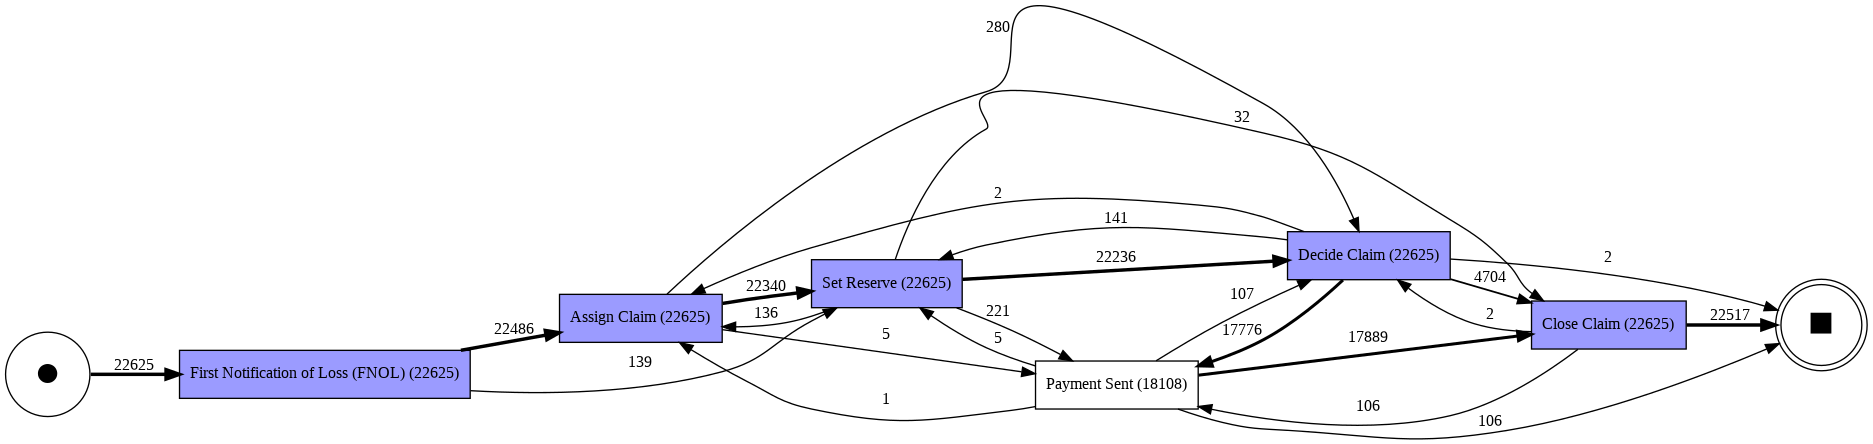

In [ ]:
# Generate the DFG process map ("directly follows graph").
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)
pm4py.view_dfg(dfg, start_activities, end_activities)

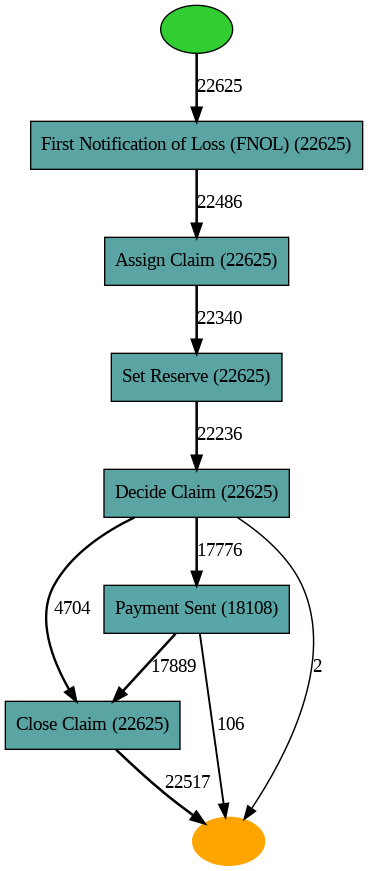

In [ ]:
# Generate the HM process map ("heuristics miner").
# Simplifies the flow and removes some of the noise.
map = pm4py.discover_heuristics_net(event_log)
pm4py.view_heuristics_net(map)

In [ ]:
# Dig deeper into the 139 Cases that went from FNOL to Set Reserve without first getting an assigned case number
# Ensure sorting is done by case_id and timestamp so that we get a chronological layout.
event_log = event_log.sort_values(by=['case_id', 'timestamp'])

# Create next activity column
event_log['next_activity'] = event_log.groupby('case_id')['activity_name'].shift(-1)

# Filter for FNOL → Set Reserve
fnol_to_reserve = event_log[
    (event_log['activity_name'] == 'First Notification of Loss (FNOL)') &
    (event_log['next_activity'] == 'Set Reserve')
]

# Get unique case IDs
cases_fnol_to_reserve = fnol_to_reserve['case_id'].unique()

# Get the cases by case_id and timestamp
filtered_cases = event_log[event_log['case_id'].isin(cases_fnol_to_reserve)]
filtered_cases.sort_values(['case_id', 'timestamp'])

,case_id,activity_name,timestamp,claim_amount,car_make,car_model,car_year,type_of_accident,case:concept:name,concept:name,time:timestamp,@@index,@@case_index,start_timestamp,next_activity
1584,022a6999-d4eb-4c3f-98cd-138527464ea0,First Notification of Loss (FNOL),2021-07-20 09:18:00+00:00,4316.16,Jeep,Wrangler,2019,Side-impact,022a6999-d4eb-4c3f-98cd-138527464ea0,First Notification of Loss (FNOL),2021-07-20 09:18:00+00:00,1584,264,2021-07-20 09:18:00+00:00,Set Reserve
1585,022a6999-d4eb-4c3f-98cd-138527464ea0,Set Reserve,2021-08-04 10:03:00+00:00,4316.16,Jeep,Wrangler,2019,Side-impact,022a6999-d4eb-4c3f-98cd-138527464ea0,Set Reserve,2021-08-04 10:03:00+00:00,1585,264,2021-08-04 10:03:00+00:00,Assign Claim
1586,022a6999-d4eb-4c3f-98cd-138527464ea0,Assign Claim,2021-08-05 23:16:00+00:00,4316.16,Jeep,Wrangler,2019,Side-impact,022a6999-d4eb-4c3f-98cd-138527464ea0,Assign Claim,2021-08-05 23:16:00+00:00,1586,264,2021-08-05 23:16:00+00:00,Decide Claim
1587,022a6999-d4eb-4c3f-98cd-138527464ea0,Decide Claim,2021-08-10 00:15:00+00:00,4316.16,Jeep,Wrangler,2019,Side-impact,022a6999-d4eb-4c3f-98cd-138527464ea0,Decide Claim,2021-08-10 00:15:00+00:00,1587,264,2021-08-10 00:15:00+00:00,Payment Sent
1588,022a6999-d4eb-4c3f-98cd-138527464ea0,Payment Sent,2021-08-13 16:43:00+00:00,4316.16,Jeep,Wrangler,2019,Side-impact,022a6999-d4eb-4c3f-98cd-138527464ea0,Payment Sent,2021-08-13 16:43:00+00:00,1588,264,2021-08-13 16:43:00+00:00,Close Claim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130856,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Set Reserve,2022-03-24 15:52:00+00:00,6379.65,Jeep,Wrangler,2014,Rollover,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Set Reserve,2022-03-24 15:52:00+00:00,130856,22562,2022-03-24 15:52:00+00:00,Assign Claim
130857,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Assign Claim,2022-03-25 23:29:00+00:00,6379.65,Jeep,Wrangler,2014,Rollover,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Assign Claim,2022-03-25 23:29:00+00:00,130857,22562,2022-03-25 23:29:00+00:00,Decide Claim
130858,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Decide Claim,2022-03-28 23:08:00+00:00,6379.65,Jeep,Wrangler,2014,Rollover,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Decide Claim,2022-03-28 23:08:00+00:00,130858,22562,2022-03-28 23:08:00+00:00,Payment Sent
130859,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Payment Sent,2022-04-04 01:40:00+00:00,6379.65,Jeep,Wrangler,2014,Rollover,bf20fcc3-6b2b-4e10-808f-0cd1b9791a6e,Payment Sent,2022-04-04 01:40:00+00:00,130859,22562,2022-04-04 01:40:00+00:00,Close Claim
